In [6]:
import pandas as pandas
import numpy as np

In [7]:
df=pandas.read_csv('datasetM.csv')

In [8]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],1490
Process temperature [K],1520
Rotational speed [rpm],1537
Torque [Nm],1517
Tool wear [min],1518
Machine failure,0
TWF,0


In [9]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1936,M16795,Medium,NaN,307.9,2754,82.0959022,42.0,0,0,0,0,0,0
1,6495,L53674,Low,300.6,309.7,1617,31.68412504,185.0,0,0,0,0,0,0
2,1721,L48900,Low,NaN,307.7,1459,45.13900611,89.0,0,0,0,0,0,0
3,9121,L56300,L,297.4,308.4,1525,39.89688289,62.0,0,0,0,0,0,0
4,361,M15220,M,297.5,308.3,1521,36.93240173,74.0,0,0,0,0,0,0


DROP UNRELATED COLUMNS FOR CLASSIFICATION

In [10]:
df1=df.copy()

In [11]:
df1.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1936,M16795,Medium,NaN,307.9,2754,82.0959022,42.0,0,0,0,0,0,0
1,6495,L53674,Low,300.6,309.7,1617,31.68412504,185.0,0,0,0,0,0,0
2,1721,L48900,Low,NaN,307.7,1459,45.13900611,89.0,0,0,0,0,0,0
3,9121,L56300,L,297.4,308.4,1525,39.89688289,62.0,0,0,0,0,0,0
4,361,M15220,M,297.5,308.3,1521,36.93240173,74.0,0,0,0,0,0,0


In [12]:
df1=df.drop(['UDI','Product ID','Machine failure'],axis=1)

In [13]:
df1.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,Medium,NaN,307.9,2754,82.0959022,42.0,0,0,0,0,0
1,Low,300.6,309.7,1617,31.68412504,185.0,0,0,0,0,0
2,Low,NaN,307.7,1459,45.13900611,89.0,0,0,0,0,0
3,L,297.4,308.4,1525,39.89688289,62.0,0,0,0,0,0
4,M,297.5,308.3,1521,36.93240173,74.0,0,0,0,0,0


In [14]:
df1.shape

(12000, 11)

In [15]:
df1.columns = df1.columns.str.lower()

In [16]:
df1.head()

,type,air temperature [k],process temperature [k],rotational speed [rpm],torque [nm],tool wear [min],twf,hdf,pwf,osf,rnf
0,Medium,NaN,307.9,2754,82.0959022,42.0,0,0,0,0,0
1,Low,300.6,309.7,1617,31.68412504,185.0,0,0,0,0,0
2,Low,NaN,307.7,1459,45.13900611,89.0,0,0,0,0,0
3,L,297.4,308.4,1525,39.89688289,62.0,0,0,0,0,0
4,M,297.5,308.3,1521,36.93240173,74.0,0,0,0,0,0


REMOVE SPECIAL CHARACTERS AND CHARACTERS FROM COUNTINOUUS VALUE COLUMNS

In [17]:
# Check for non-numeric values in 'air temperature [k]' column
print("Before cleaning:")
print(f"Shape: {df1.shape}")
print(f"Data type: {df1['air temperature [k]'].dtype}")

# Convert to numeric, non-numeric values will become NaN
df1['air temperature [k]'] = pandas.to_numeric(df1['air temperature [k]'], errors='coerce')

# Check how many non-numeric values were found
non_numeric_count = df1['air temperature [k]'].isnull().sum()
print(f"Non-numeric values found: {non_numeric_count}")

# Remove rows with non-numeric values (NaN)
df1 = df1.dropna(subset=['air temperature [k]'])

print("\nAfter cleaning:")
print(f"Shape: {df1.shape}")
print(f"Rows removed: {non_numeric_count}")

Before cleaning:
Shape: (12000, 11)
Data type: object
Non-numeric values found: 1491

After cleaning:
Shape: (10509, 11)
Rows removed: 1491


MISSING VALUES

In [18]:
df1.isnull().sum()

,0
type,0
air temperature [k],0
process temperature [k],1282
rotational speed [rpm],1300
torque [nm],1296
tool wear [min],1345
twf,0
hdf,0
pwf,0
osf,0


In [19]:
df2=df1.copy()

In [20]:
df2 = df2.dropna(subset=['process temperature [k]'])

In [21]:
df2.isnull().sum()

,0
type,0
air temperature [k],0
process temperature [k],0
rotational speed [rpm],1098
torque [nm],1112
tool wear [min],1155
twf,0
hdf,0
pwf,0
osf,0


In [22]:
df2.shape

(9227, 11)

NOW WE ARE GOING TO ADD THE MEAN VALUE FOR NULL AREAS, BECAUSE ALREADY THE DATASET SIZE REDUCED.

In [23]:
# Check for non-numeric values in specified columns (excluding NaN/null values)
columns_to_check = ['tool wear [min]', 'torque [nm]', 'rotational speed [rpm]', 'twf', 'hdf', 'pwf', 'osf', 'rnf']

print("Before cleaning non-numeric values:")
print(f"Shape: {df2.shape}")

for col in columns_to_check:
    print(f"\nChecking column: {col}")
    print(f"Data type: {df2[col].dtype}")

    # Create a mask for non-null values that are not numeric
    non_null_mask = df2[col].notna()  # Only check non-null values

    if non_null_mask.any():
        # Try to convert to numeric, errors='coerce' makes invalid parsing NaN
        temp_numeric = pandas.to_numeric(df2.loc[non_null_mask, col], errors='coerce')

        # Find non-numeric values (but exclude original NaN values)
        non_numeric_mask = temp_numeric.isna() & non_null_mask
        non_numeric_count = non_numeric_mask.sum()

        if non_numeric_count > 0:
            print(f"Non-numeric values found: {non_numeric_count}")
            print(f"Sample non-numeric values: {df2.loc[non_numeric_mask, col].unique()[:5]}")

            # Remove rows with non-numeric values (but keep original NaN rows)
            df2 = df2[~non_numeric_mask]
        else:
            print("No non-numeric values found")

print(f"\nAfter cleaning:")
print(f"Shape: {df2.shape}")
print("\nRemaining null values:")
print(df2[columns_to_check].isnull().sum())

Before cleaning non-numeric values:
Shape: (9227, 11)

Checking column: tool wear [min]
Data type: float64
No non-numeric values found

Checking column: torque [nm]
Data type: object
Non-numeric values found: 14
Sample non-numeric values: ['yyuyj' 'dgdfg' '19.9807478016fgbh985' 'dgdfg4' '5hhb']

Checking column: rotational speed [rpm]
Data type: object
Non-numeric values found: 5
Sample non-numeric values: ['rf1401' '15rr06' '467u4u' '46u7']

Checking column: twf
Data type: int64
No non-numeric values found

Checking column: hdf
Data type: int64
No non-numeric values found

Checking column: pwf
Data type: object
Non-numeric values found: 1
Sample non-numeric values: ['fgbd']

Checking column: osf
Data type: object
Non-numeric values found: 2
Sample non-numeric values: ['rsth' 'srthg']

Checking column: rnf
Data type: int64
No non-numeric values found

After cleaning:
Shape: (9205, 11)

Remaining null values:
tool wear [min]           1152
torque [nm]               1112
rotational speed

In [24]:
df2.shape

(9205, 11)

In [25]:
# Fill null values with mean for numeric columns
print("Before filling null values:")
print(df2.isnull().sum())

# Calculate and fill mean for columns with null values
numeric_columns = ['tool wear [min]', 'torque [nm]', 'rotational speed [rpm]', 'twf', 'hdf', 'pwf', 'osf', 'rnf']

for col in numeric_columns:
    if df2[col].isnull().sum() > 0:
        # Convert to numeric first, non-numeric values become NaN
        df2[col] = pandas.to_numeric(df2[col], errors='coerce')

        # Calculate mean of numeric values only
        mean_value = df2[col].mean()

        # Fill null values with mean
        df2[col] = df2[col].fillna(mean_value)
        print(f"Filled {col} null values with mean: {mean_value:.2f}")

print("\nAfter filling null values:")
print(df2.isnull().sum())
print(f"\nFinal shape: {df2.shape}")

Before filling null values:
type                          0
air temperature [k]           0
process temperature [k]       0
rotational speed [rpm]     1096
torque [nm]                1112
tool wear [min]            1152
twf                           0
hdf                           0
pwf                           0
osf                           0
rnf                           0
dtype: int64
Filled tool wear [min] null values with mean: 107.69
Filled torque [nm] null values with mean: 40.89
Filled rotational speed [rpm] null values with mean: 1619.55

After filling null values:
type                       0
air temperature [k]        0
process temperature [k]    0
rotational speed [rpm]     0
torque [nm]                0
tool wear [min]            0
twf                        0
hdf                        0
pwf                        0
osf                        0
rnf                        0
dtype: int64

Final shape: (9205, 11)


In [26]:
df2.shape

(9205, 11)

In [27]:
df2.isnull().sum()

,0
type,0
air temperature [k],0
process temperature [k],0
rotational speed [rpm],0
torque [nm],0
tool wear [min],0
twf,0
hdf,0
pwf,0
osf,0


In [28]:
df2.head()

,type,air temperature [k],process temperature [k],rotational speed [rpm],torque [nm],tool wear [min],twf,hdf,pwf,osf,rnf
1,Low,300.6,309.7,1617.0,31.684125,185.0,0,0,0,0,0
3,L,297.4,308.4,1525.0,39.896883,62.0,0,0,0,0,0
4,M,297.5,308.3,1521.0,36.932402,74.0,0,0,0,0,0
5,Low,299.1,310.1,1435.0,48.766382,229.0,0,0,0,1,0
6,L,303.5,312.9,1501.0,44.777130,128.0,0,0,0,0,0


STANDADIZING THE TYPE COLUMN TO L,M,H

In [29]:
# Clean and standardize the 'type' column
print("Before cleaning 'type' column:")
print(df2['type'].value_counts())

# Strip whitespace and convert to uppercase for processing
df2['type'] = df2['type'].astype(str).str.strip().str.upper()

# Create a function to standardize the values
def standardize_type(value):
    if pandas.isna(value) or value == 'NAN':
        return np.nan

    # Get the first letter
    first_letter = value[0] if len(value) > 0 else ''

    if first_letter == 'L':
        return 'L'
    elif first_letter == 'M':
        return 'M'
    elif first_letter == 'H':
        return 'H'
    else:
        return np.nan

# Apply the standardization
df2['type'] = df2['type'].apply(standardize_type)

print("\nAfter cleaning 'type' column:")
print(df2['type'].value_counts())
print(f"\nNull values in 'type': {df2['type'].isnull().sum()}")

Before cleaning 'type' column:
type
L          1773
Low        1636
l          1596
M           940
m           819
Medium      814
H           449
High        274
h           269
low         166
invalid     161
hi          158
med         150
Name: count, dtype: int64

After cleaning 'type' column:
type
L    5171
M    2723
H    1150
Name: count, dtype: int64

Null values in 'type': 161


In [30]:
df2.shape

(9205, 11)

In [31]:
df2.isnull().sum()

,0
type,161
air temperature [k],0
process temperature [k],0
rotational speed [rpm],0
torque [nm],0
tool wear [min],0
twf,0
hdf,0
pwf,0
osf,0


In [32]:
#drop null values in type column
df2 = df2.dropna(subset=['type'])

In [33]:
df2.isnull().sum()

,0
type,0
air temperature [k],0
process temperature [k],0
rotational speed [rpm],0
torque [nm],0
tool wear [min],0
twf,0
hdf,0
pwf,0
osf,0


In [34]:
# Since we are doing multi-class classification for the specific type of failure, our target will be one of:
# TWF = Tool Wear Failure
# HDF = Heat Dissipation Failure
# PWF = Power Failure
# OSF = Overstrain Failure
# RNF = Random Failures
# 📌 Problem: our dataset currently has these as separate binary columns (0/1).
# 👉 For multi-class classification, you need to combine them into one column.

In [35]:
def assign_failure(row):
    if row['twf'] == 1: return "twf"
    elif row['hdf'] == 1: return "hdf"
    elif row['pwf'] == 1: return "pwf"
    elif row['osf'] == 1: return "osf"
    elif row['rnf'] == 1: return "rnf"
    else: return "Healthy"   # no failure

df2["Failure_Type"] = df2.apply(assign_failure, axis=1)

In [36]:
df2.head()

,type,air temperature [k],process temperature [k],rotational speed [rpm],torque [nm],tool wear [min],twf,hdf,pwf,osf,rnf,Failure_Type
1,L,300.6,309.7,1617.0,31.684125,185.0,0,0,0,0,0,Healthy
3,L,297.4,308.4,1525.0,39.896883,62.0,0,0,0,0,0,Healthy
4,M,297.5,308.3,1521.0,36.932402,74.0,0,0,0,0,0,Healthy
5,L,299.1,310.1,1435.0,48.766382,229.0,0,0,0,1,0,Healthy
6,L,303.5,312.9,1501.0,44.777130,128.0,0,0,0,0,0,Healthy


In [37]:
df3=df2.copy()

In [38]:
df3.head()

,type,air temperature [k],process temperature [k],rotational speed [rpm],torque [nm],tool wear [min],twf,hdf,pwf,osf,rnf,Failure_Type
1,L,300.6,309.7,1617.0,31.684125,185.0,0,0,0,0,0,Healthy
3,L,297.4,308.4,1525.0,39.896883,62.0,0,0,0,0,0,Healthy
4,M,297.5,308.3,1521.0,36.932402,74.0,0,0,0,0,0,Healthy
5,L,299.1,310.1,1435.0,48.766382,229.0,0,0,0,1,0,Healthy
6,L,303.5,312.9,1501.0,44.777130,128.0,0,0,0,0,0,Healthy


In [39]:
df3=df3.drop(['twf','hdf','pwf','osf','rnf'],axis=1)

In [40]:
df3.columns=df3.columns.str.lower()

In [41]:
df3.head()

,type,air temperature [k],process temperature [k],rotational speed [rpm],torque [nm],tool wear [min],failure_type
1,L,300.6,309.7,1617.0,31.684125,185.0,Healthy
3,L,297.4,308.4,1525.0,39.896883,62.0,Healthy
4,M,297.5,308.3,1521.0,36.932402,74.0,Healthy
5,L,299.1,310.1,1435.0,48.766382,229.0,Healthy
6,L,303.5,312.9,1501.0,44.777130,128.0,Healthy


BOUNDARY & OUTLIER ANALYSIS

In [42]:
df3.describe()

,air temperature [k],rotational speed [rpm],torque [nm],tool wear [min]
count,9044.000000,9044.000000,9044.000000,9044.000000
mean,300.036005,1619.628436,40.934280,107.728982
std,2.571319,372.954244,10.658033,59.567992
min,281.614811,1168.000000,3.650584,-5.756216
25%,298.300000,1439.000000,34.415598,60.000000
50%,300.100000,1541.000000,40.891062,107.690882
75%,301.700000,1619.549862,46.679335,155.000000
max,315.605616,5442.000000,103.627854,251.000000


In [43]:
df3.shape

(9044, 7)

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

In [45]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_percentage': (len(outliers) / len(df)) * 100
    }

In [46]:
# Define numeric columns for outlier detection
numeric_cols = ['air temperature [k]', 'rotational speed [rpm]', 'torque [nm]', 'tool wear [min]']

print("=== OUTLIER DETECTION AND BOUNDARY VALUES ===\n")

# Analyze each numeric column
outlier_summary = {}
for col in numeric_cols:
    print(f"\n--- {col.upper()} ---")
    stats = detect_outliers_iqr(df3, col)
    outlier_summary[col] = stats

    print(f"Q1 (25th percentile): {stats['Q1']:.2f}")
    print(f"Q3 (75th percentile): {stats['Q3']:.2f}")
    print(f"IQR: {stats['IQR']:.2f}")
    print(f"Lower boundary: {stats['lower_bound']:.2f}")
    print(f"Upper boundary: {stats['upper_bound']:.2f}")
    print(f"Outliers found: {stats['outlier_count']} ({stats['outlier_percentage']:.2f}%)")

=== OUTLIER DETECTION AND BOUNDARY VALUES ===


--- AIR TEMPERATURE [K] ---
Q1 (25th percentile): 298.30
Q3 (75th percentile): 301.70
IQR: 3.40
Lower boundary: 293.20
Upper boundary: 306.80
Outliers found: 199 (2.20%)

--- ROTATIONAL SPEED [RPM] ---
Q1 (25th percentile): 1439.00
Q3 (75th percentile): 1619.55
IQR: 180.55
Lower boundary: 1168.18
Upper boundary: 1890.37
Outliers found: 742 (8.20%)

--- TORQUE [NM] ---
Q1 (25th percentile): 34.42
Q3 (75th percentile): 46.68
IQR: 12.26
Lower boundary: 16.02
Upper boundary: 65.07
Outliers found: 261 (2.89%)

--- TOOL WEAR [MIN] ---
Q1 (25th percentile): 60.00
Q3 (75th percentile): 155.00
IQR: 95.00
Lower boundary: -82.50
Upper boundary: 297.50
Outliers found: 0 (0.00%)


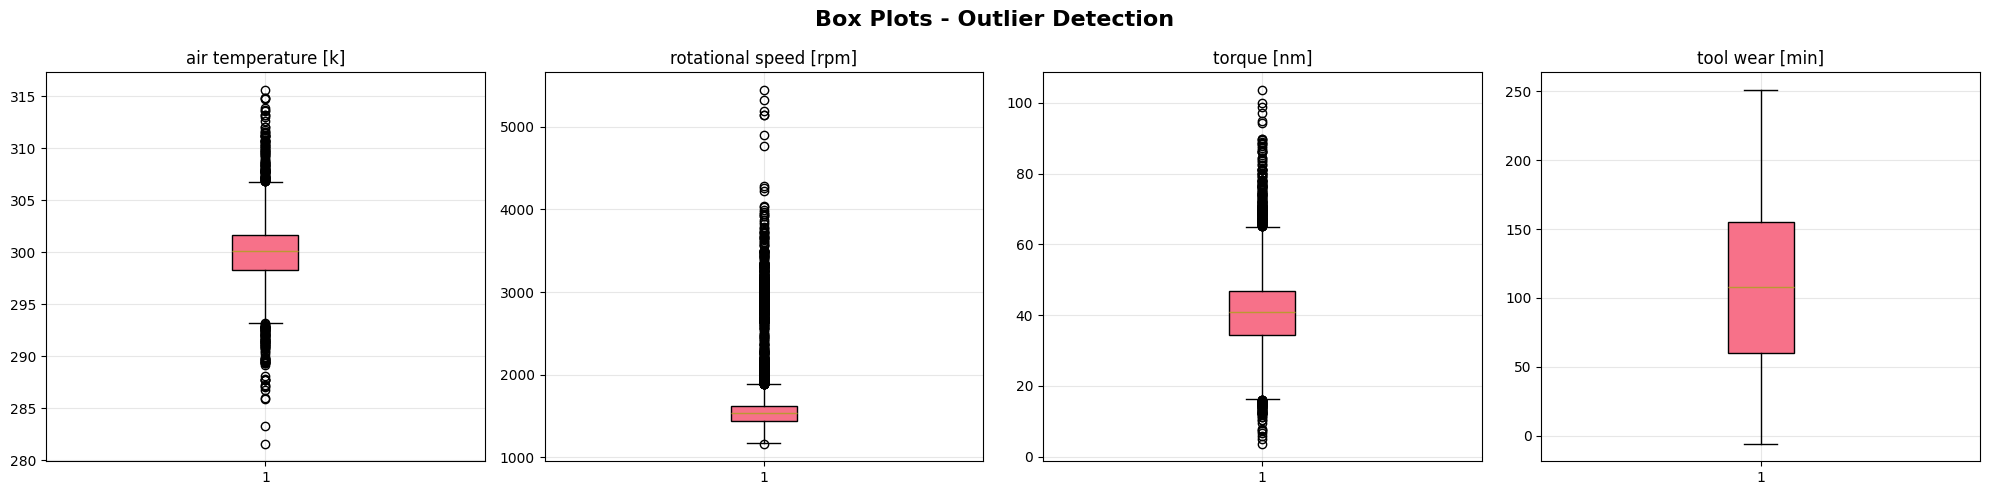

In [47]:
# Create box plots for outlier visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df3[col].dropna(), patch_artist=True)
    axes[i].set_title(f'{col}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

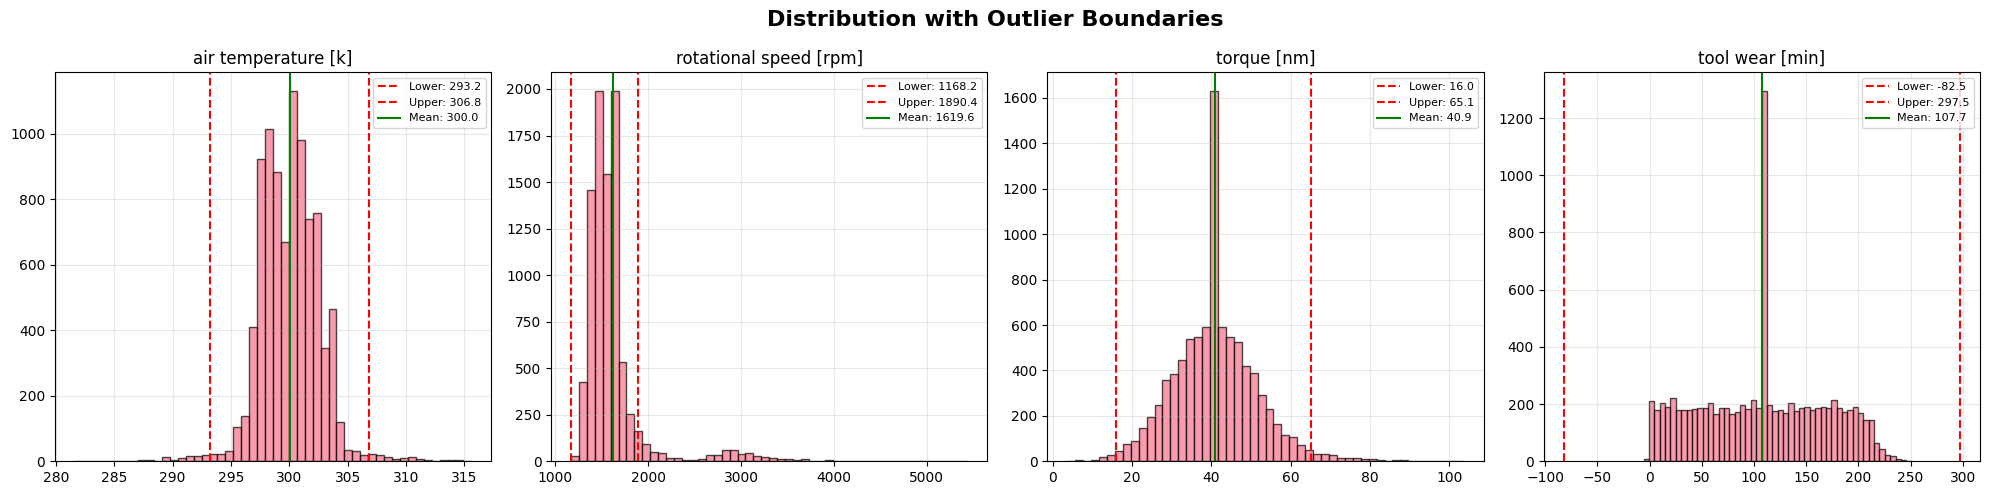

In [48]:
# Create histograms with boundary lines
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Distribution with Outlier Boundaries', fontsize=16, fontweight='bold')

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[i].hist(df3[col].dropna(), bins=50, alpha=0.7, edgecolor='black')

    # Add boundary lines
    stats = outlier_summary[col]
    axes[i].axvline(stats['lower_bound'], color='red', linestyle='--',
                   label=f'Lower: {stats["lower_bound"]:.1f}')
    axes[i].axvline(stats['upper_bound'], color='red', linestyle='--',
                   label=f'Upper: {stats["upper_bound"]:.1f}')
    axes[i].axvline(df3[col].mean(), color='green', linestyle='-',
                   label=f'Mean: {df3[col].mean():.1f}')

    axes[i].set_title(f'{col}')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
# Summary table
print("=== OUTLIER SUMMARY TABLE ===")
summary_df = pandas.DataFrame(outlier_summary).T
summary_df = summary_df.round(2)
print(summary_df)

=== OUTLIER SUMMARY TABLE ===
                             Q1       Q3     IQR  lower_bound  upper_bound  \
air temperature [k]      298.30   301.70    3.40       293.20       306.80   
rotational speed [rpm]  1439.00  1619.55  180.55      1168.18      1890.37   
torque [nm]               34.42    46.68   12.26        16.02        65.07   
tool wear [min]           60.00   155.00   95.00       -82.50       297.50   

                        outlier_count  outlier_percentage  
air temperature [k]             199.0                2.20  
rotational speed [rpm]          742.0                8.20  
torque [nm]                     261.0                2.89  
tool wear [min]                   0.0                0.00  


In [50]:
# Identify extreme outliers (beyond 3*IQR)
print("=== EXTREME OUTLIERS (3*IQR METHOD) ===")
for col in numeric_cols:
    Q1 = df3[col].quantile(0.25)
    Q3 = df3[col].quantile(0.75)
    IQR = Q3 - Q1
    extreme_lower = Q1 - 3 * IQR
    extreme_upper = Q3 + 3 * IQR

    extreme_outliers = df3[(df3[col] < extreme_lower) | (df3[col] > extreme_upper)]
    print(f"{col}: {len(extreme_outliers)} extreme outliers ({(len(extreme_outliers)/len(df3))*100:.2f}%)")

=== EXTREME OUTLIERS (3*IQR METHOD) ===
air temperature [k]: 25 extreme outliers (0.28%)
rotational speed [rpm]: 493 extreme outliers (5.45%)
torque [nm]: 24 extreme outliers (0.27%)
tool wear [min]: 0 extreme outliers (0.00%)


In [51]:
# Remove extreme outliers (beyond 3*IQR)
print("=== REMOVING EXTREME OUTLIERS (3*IQR METHOD) ===")
print(f"Shape before removing outliers: {df3.shape}")

for col in numeric_cols:
    Q1 = df3[col].quantile(0.25)
    Q3 = df3[col].quantile(0.75)
    IQR = Q3 - Q1
    extreme_lower = Q1 - 3 * IQR
    extreme_upper = Q3 + 3 * IQR

    # Count outliers before removal
    extreme_outliers = df3[(df3[col] < extreme_lower) | (df3[col] > extreme_upper)]
    outlier_count = len(extreme_outliers)

    if outlier_count > 0:
        print(f"\n{col}: Removing {outlier_count} extreme outliers ({(outlier_count/len(df3))*100:.2f}%)")

        # Remove extreme outliers
        df3 = df3[(df3[col] >= extreme_lower) & (df3[col] <= extreme_upper)]
    else:
        print(f"\n{col}: No extreme outliers found")

print(f"\nShape after removing outliers: {df3.shape}")
print(f"Total rows removed: {9060 - df3.shape[0]}")

=== REMOVING EXTREME OUTLIERS (3*IQR METHOD) ===
Shape before removing outliers: (9044, 7)

air temperature [k]: Removing 25 extreme outliers (0.28%)

rotational speed [rpm]: Removing 493 extreme outliers (5.47%)

torque [nm]: Removing 2 extreme outliers (0.02%)

tool wear [min]: No extreme outliers found

Shape after removing outliers: (8524, 7)
Total rows removed: 536


In [52]:
df3.shape

(8524, 7)

In [53]:
df3.describe()

,air temperature [k],rotational speed [rpm],torque [nm],tool wear [min]
count,8524.000000,8524.000000,8524.000000,8524.000000
mean,300.047234,1541.392201,40.356561,107.894964
std,2.473904,147.588424,9.387062,59.644912
min,288.152397,1168.000000,6.690435,-5.756216
25%,298.300000,1434.000000,34.332837,60.000000
50%,300.100000,1528.000000,40.891062,107.690882
75%,301.700000,1619.549862,46.049632,155.000000
max,311.779990,2161.000000,81.135765,251.000000


In [54]:
df3.head(50)

,type,air temperature [k],process temperature [k],rotational speed [rpm],torque [nm],tool wear [min],failure_type
1,L,300.600000,309.7,1617.000000,31.684125,185.000000,Healthy
3,L,297.400000,308.4,1525.000000,39.896883,62.000000,Healthy
4,M,297.500000,308.3,1521.000000,36.932402,74.000000,Healthy
5,L,299.100000,310.1,1435.000000,48.766382,229.000000,Healthy
6,L,303.500000,312.9,1501.000000,44.777130,128.000000,Healthy
8,L,299.600000,309,1372.000000,61.473290,149.000000,Healthy
9,M,303.100000,311.4,1619.549862,22.696837,161.000000,Healthy
10,M,301.800000,310.7,1383.000000,46.117700,44.000000,Healthy
12,L,297.300000,308.7,1619.000000,32.751842,129.000000,Healthy
13,M,297.200000,jnij,1578.000000,39.397907,3.000000,Healthy


CHECK CLASS IMBALANCE

In [55]:
df3.failure_type.value_counts()

,count
failure_type,
Healthy,8235
hdf,151
twf,85
rnf,53


THE TARGET IS IMBALANCED. WE HAVE 2 OPTIONS
1) Class Weighting (preferred with XGBoost)
2) SMOTE (Synthetic Minority Over-sampling Technique)


In [56]:
# Save the cleaned dataset
df3.to_csv('cleaned_dataset.csv', index=False)
print(f"Cleaned dataset saved as 'cleaned_dataset.csv'")
print(f"Final dataset shape: {df3.shape}")
print(f"Columns: {list(df3.columns)}")

Cleaned dataset saved as 'cleaned_dataset.csv'
Final dataset shape: (8524, 7)
Columns: ['type', 'air temperature [k]', 'process temperature [k]', 'rotational speed [rpm]', 'torque [nm]', 'tool wear [min]', 'failure_type']


# GOT ERROR WHEN TRAINGN
![image.png](attachment:image.png)



In [57]:
# Check for non-numeric values in the dataset
print("Data types:")
print(df3.dtypes)
print("\nChecking for non-numeric values in numeric columns:")

numeric_cols = ['air temperature [k]', 'process temperature [k]', 'rotational speed [rpm]',
                'torque [nm]', 'tool wear [min]']

for col in numeric_cols:
    non_numeric = df3[col].apply(lambda x: not str(x).replace('.', '').replace('-', '').isdigit())
    if non_numeric.any():
        print(f"\n{col} has non-numeric values:")
        print(df3.loc[non_numeric, col].unique()[:10])  # Show first 10 unique non-numeric values

Data types:
type                        object
air temperature [k]        float64
process temperature [k]     object
rotational speed [rpm]     float64
torque [nm]                float64
tool wear [min]            float64
failure_type                object
dtype: object

Checking for non-numeric values in numeric columns:

process temperature [k] has non-numeric values:
['jnij' 'jmmog56' 'ghmnom' 'jhjh589' '46u75' '46u7u7' '46u74']


In [58]:
import pandas as pd

In [59]:
# Clean non-numeric values in process temperature column
print("Before cleaning:")
print(f"Process temperature data type: {df3['process temperature [k]'].dtype}")
print(f"Sample non-numeric values: {df3['process temperature [k]'].apply(lambda x: not str(x).replace('.', '').replace('-', '').isdigit()).sum()}")

# Convert to numeric, invalid values become NaN
df3['process temperature [k]'] = pd.to_numeric(df3['process temperature [k]'], errors='coerce')

# Check for NaN values after conversion
print(f"\nAfter cleaning:")
print(f"NaN values in process temperature: {df3['process temperature [k]'].isnull().sum()}")
print(f"Total rows before cleaning: {len(df3)}")

# Drop rows with NaN values in process temperature
df_clean = df3.dropna(subset=['process temperature [k]'])
print(f"Total rows after cleaning: {len(df_clean)}")
print(f"Rows removed: {len(df3) - len(df_clean)}")

Before cleaning:
Process temperature data type: object
Sample non-numeric values: 7

After cleaning:
NaN values in process temperature: 7
Total rows before cleaning: 8524
Total rows after cleaning: 8517
Rows removed: 7


In [63]:
df = df.drop_duplicates()


In [64]:
df_clean.shape

(8517, 7)

In [65]:
# # Save the cleaned dataset
df_clean.to_csv('cleaned_dataset.csv', index=False)
print(f"Cleaned dataset saved as 'cleaned_dataset.csv'")
print(f"Final dataset shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

Cleaned dataset saved as 'cleaned_dataset.csv'
Final dataset shape: (8517, 7)
Columns: ['type', 'air temperature [k]', 'process temperature [k]', 'rotational speed [rpm]', 'torque [nm]', 'tool wear [min]', 'failure_type']
